In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import cars
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_csv('data/nhtsa_vehicle_safety_recall_intelligence_ultimate.csv')

df.head()

,record_id,nhtsa_record_id,recall_campaign_id,manufacturer_campaign_id,vehicle_make,vehicle_model,vehicle_year,vehicle_year_num,vehicle_era,manufacturer_name,...,source_url,scrape_date,dataset_version,record_creation_date,RCL_CMPT_ID,MFR_COMP_NAME,MFR_COMP_DESC,MFR_COMP_PTNO,creation_date_parsed,defect_severity_score
0,835d8908b3a39d,105867,14V400000,14350,OLDSMOBILE,INTRIGUE,1998.0,1998.0,1990s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202679000000212,NaN,NaN,NaN,2014-07-07,0.3979
1,1e393b1efc0ea4,105872,14V400000,14350,CHEVROLET,MALIBU CLASSIC,2005.0,2005.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000204360000000212,NaN,NaN,NaN,2014-07-07,0.3979
2,1ea55f8d43bf01,105885,14V400000,14350,OLDSMOBILE,ALERO,2001.0,2001.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202733000000212,NaN,NaN,NaN,2014-07-07,0.3979
3,3588d2734c086b,105883,14V400000,14350,PONTIAC,GRAND AM,2000.0,2000.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202623000000212,NaN,NaN,NaN,2014-07-07,0.3979
4,ab8db036507579,105882,14V400000,14350,PONTIAC,GRAND AM,2002.0,2002.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202625000000212,NaN,NaN,NaN,2014-07-07,0.3979


# Pre-processing

In [6]:
recall = df['recall_type_label'].unique()
recall

<StringArray>
['Vehicle', 'Equipment', 'Child Seat', 'Tire']
Length: 4, dtype: str

In [7]:
df = df[df['recall_type_label'].isin(['Vehicle'])]
df.head()

,record_id,nhtsa_record_id,recall_campaign_id,manufacturer_campaign_id,vehicle_make,vehicle_model,vehicle_year,vehicle_year_num,vehicle_era,manufacturer_name,...,source_url,scrape_date,dataset_version,record_creation_date,RCL_CMPT_ID,MFR_COMP_NAME,MFR_COMP_DESC,MFR_COMP_PTNO,creation_date_parsed,defect_severity_score
0,835d8908b3a39d,105867,14V400000,14350,OLDSMOBILE,INTRIGUE,1998.0,1998.0,1990s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202679000000212,NaN,NaN,NaN,2014-07-07,0.3979
1,1e393b1efc0ea4,105872,14V400000,14350,CHEVROLET,MALIBU CLASSIC,2005.0,2005.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000204360000000212,NaN,NaN,NaN,2014-07-07,0.3979
2,1ea55f8d43bf01,105885,14V400000,14350,OLDSMOBILE,ALERO,2001.0,2001.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202733000000212,NaN,NaN,NaN,2014-07-07,0.3979
3,3588d2734c086b,105883,14V400000,14350,PONTIAC,GRAND AM,2000.0,2000.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202623000000212,NaN,NaN,NaN,2014-07-07,0.3979
4,ab8db036507579,105882,14V400000,14350,PONTIAC,GRAND AM,2002.0,2002.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202625000000212,NaN,NaN,NaN,2014-07-07,0.3979


In [8]:
components = df['component_category'].unique()
components

<StringArray>
[            'Air Bag', 'Engine / Powertrain',          'Electrical',
              'Brakes',            'Steering',         'Fuel System',
               'Other',      'Tires / Wheels',          'Visibility',
           'Fire Risk',          'Suspension',          'Seat Belts',
       'Software / EV',          'Child Seat']
Length: 14, dtype: str

In [9]:
df = df[~df['component_category'].isin(['Child Seat', 'Other'])]
df.head()

,record_id,nhtsa_record_id,recall_campaign_id,manufacturer_campaign_id,vehicle_make,vehicle_model,vehicle_year,vehicle_year_num,vehicle_era,manufacturer_name,...,source_url,scrape_date,dataset_version,record_creation_date,RCL_CMPT_ID,MFR_COMP_NAME,MFR_COMP_DESC,MFR_COMP_PTNO,creation_date_parsed,defect_severity_score
0,835d8908b3a39d,105867,14V400000,14350,OLDSMOBILE,INTRIGUE,1998.0,1998.0,1990s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202679000000212,NaN,NaN,NaN,2014-07-07,0.3979
1,1e393b1efc0ea4,105872,14V400000,14350,CHEVROLET,MALIBU CLASSIC,2005.0,2005.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000204360000000212,NaN,NaN,NaN,2014-07-07,0.3979
2,1ea55f8d43bf01,105885,14V400000,14350,OLDSMOBILE,ALERO,2001.0,2001.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202733000000212,NaN,NaN,NaN,2014-07-07,0.3979
3,3588d2734c086b,105883,14V400000,14350,PONTIAC,GRAND AM,2000.0,2000.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202623000000212,NaN,NaN,NaN,2014-07-07,0.3979
4,ab8db036507579,105882,14V400000,14350,PONTIAC,GRAND AM,2002.0,2002.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202625000000212,NaN,NaN,NaN,2014-07-07,0.3979


In [10]:
manufacturer_campaign_ids = df['manufacturer_campaign_id'].unique()
vehicle_year = df['vehicle_year'].unique()
vehicle_year_num = df['vehicle_year_num'].unique()
vehicle_era = df['vehicle_era'].unique()

print(manufacturer_campaign_ids)
print(vehicle_year)
print(vehicle_year_num)
print(vehicle_era)

df = df.dropna()
df = df[(df['vehicle_year_num'] >=2014) & (df['vehicle_year_num'] <=2024)]

<StringArray>
[          '14350',          '17-307',           '8715J',             '251',
           'SC098',             'C0M',     '14113,14133',             'P25',
               nan,           'R22C8',
 ...
          '20TA06', '21TB10 / 21TA10',        'R20AM-SB',      'N212346640',
 'Bulletin 2020-5',        'RC000204',        'RVXX2005',            'N494',
          'TB2011',           'V2003']
Length: 3560, dtype: str
[1998. 2005. 2001. 2000. 2002. 2003. 2004. 1999. 1997. 2006. 2007. 2008.
 2014. 2010. 1993. 2011. 2016. 2013. 2017. 2015. 2009. 2012. 2018. 1989.
 2020. 2019. 2021. 2022. 2023. 1996. 1994. 1995. 2024. 1991. 1992. 1990.
 2025. 2026. 1988. 2027.   nan]
[1998. 2005. 2001. 2000. 2002. 2003. 2004. 1999. 1997. 2006. 2007. 2008.
 2014. 2010. 1993. 2011. 2016. 2013. 2017. 2015. 2009. 2012. 2018. 1989.
 2020. 2019. 2021. 2022. 2023. 1996. 1994. 1995. 2024. 1991. 1992. 1990.
 2025. 2026. 1988. 2027.   nan]
<StringArray>
['1990s', '2000s', '2010s', '1980s', '2020s', nan]
Len

# Analyse

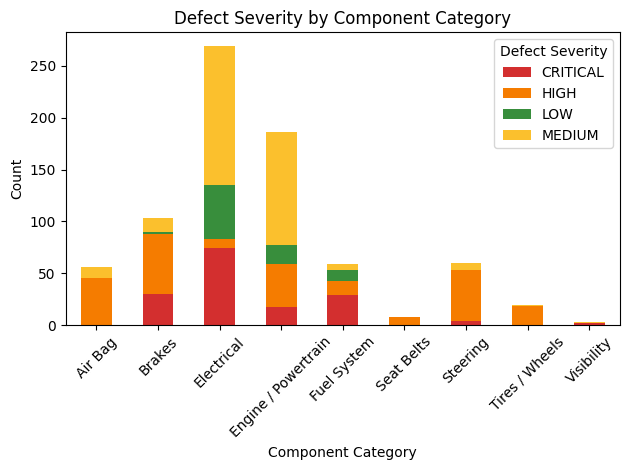

In [11]:
severity_colors = {
    'CRITICAL': '#d32f2f',
    'HIGH':     '#f57c00',
    'MEDIUM':   '#fbc02d',
    'LOW':      '#388e3c',
}

defect_severity_by_component = df.groupby('component_category')['defect_severity'].value_counts().unstack().fillna(0)
colors = [severity_colors[col] for col in defect_severity_by_component.columns]
defect_severity_by_component.plot(kind='bar', stacked=True, color=colors)
plt.title('Defect Severity by Component Category')
plt.xlabel('Component Category')
plt.ylabel('Count')
plt.legend(title='Defect Severity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
defect_severity = df['defect_severity'].unique()
defect_severity

<StringArray>
['HIGH', 'MEDIUM', 'CRITICAL', 'LOW']
Length: 4, dtype: str

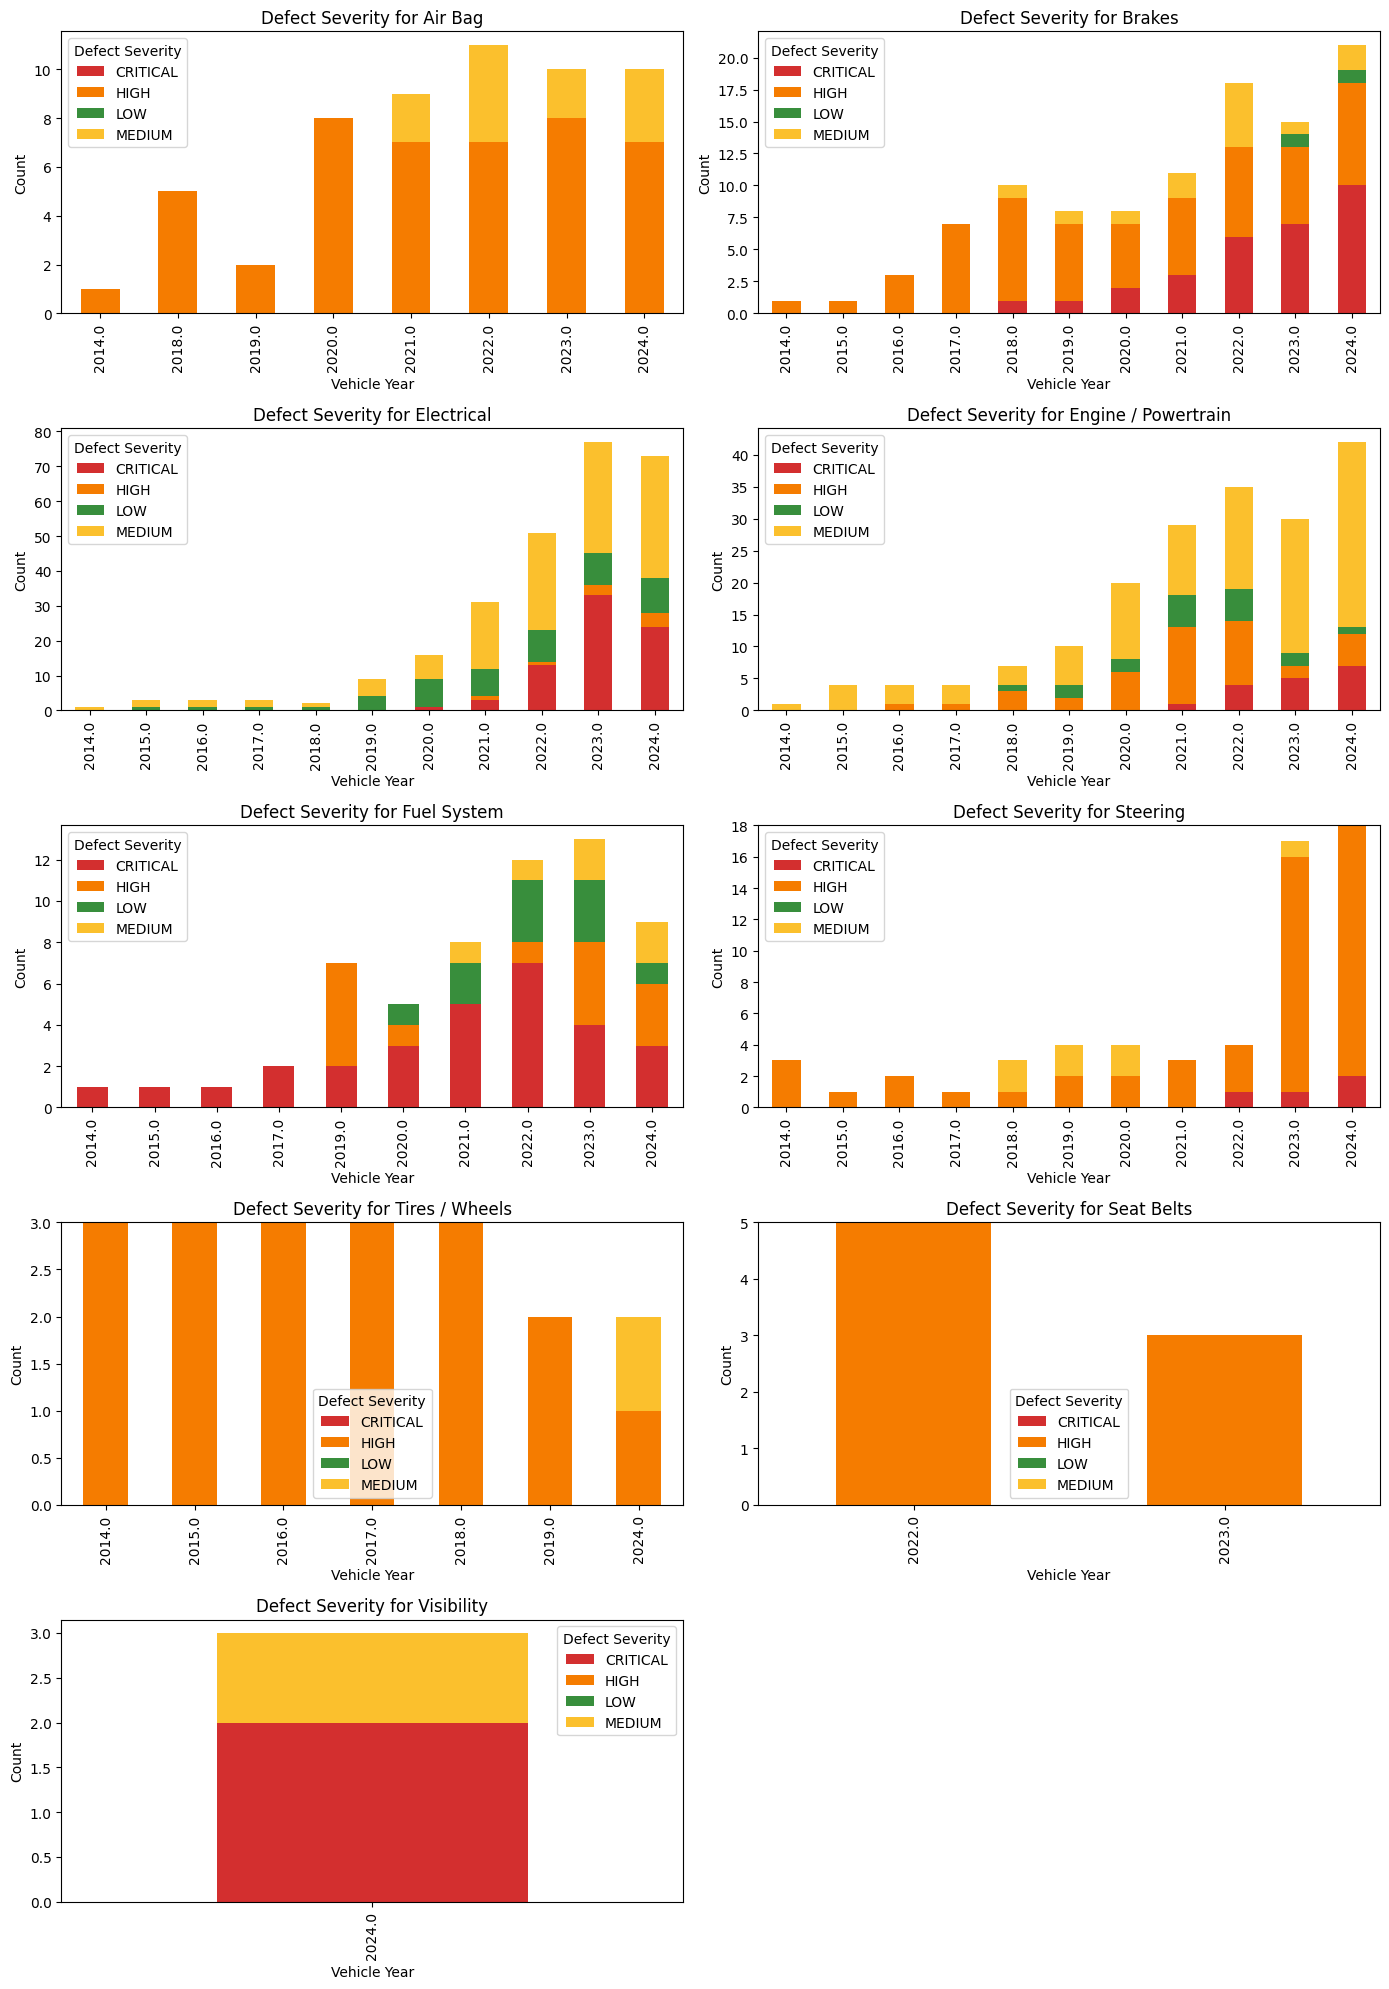

In [13]:
defect_severity_by_component_years = (
    df.groupby(['vehicle_year_num', 'component_category'])['defect_severity']
    .value_counts()
    .unstack()
    .fillna(0)
)

severity_colors = {
    'CRITICAL': '#d32f2f',
    'HIGH':     '#f57c00',
    'MEDIUM':   '#fbc02d',
    'LOW':      '#388e3c',
}

components = defect_severity_by_component_years.index.get_level_values(1).unique()
n_rows = (len(components) + 1) // 2

fig, ax = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
ax = ax.flatten()

for i, component in enumerate(components):
    data = defect_severity_by_component_years.xs(component, level=1)
    colors = [severity_colors.get(col, '#90a4ae') for col in data.columns]
    data.plot(kind='bar', stacked=True, ax=ax[i], color=colors)
    ax[i].set_title(f'Defect Severity for {component}')
    ax[i].set_xlabel('Vehicle Year')
    ax[i].set_ylabel('Count')
    ax[i].legend(title='Defect Severity')

for j in range(len(components), len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()


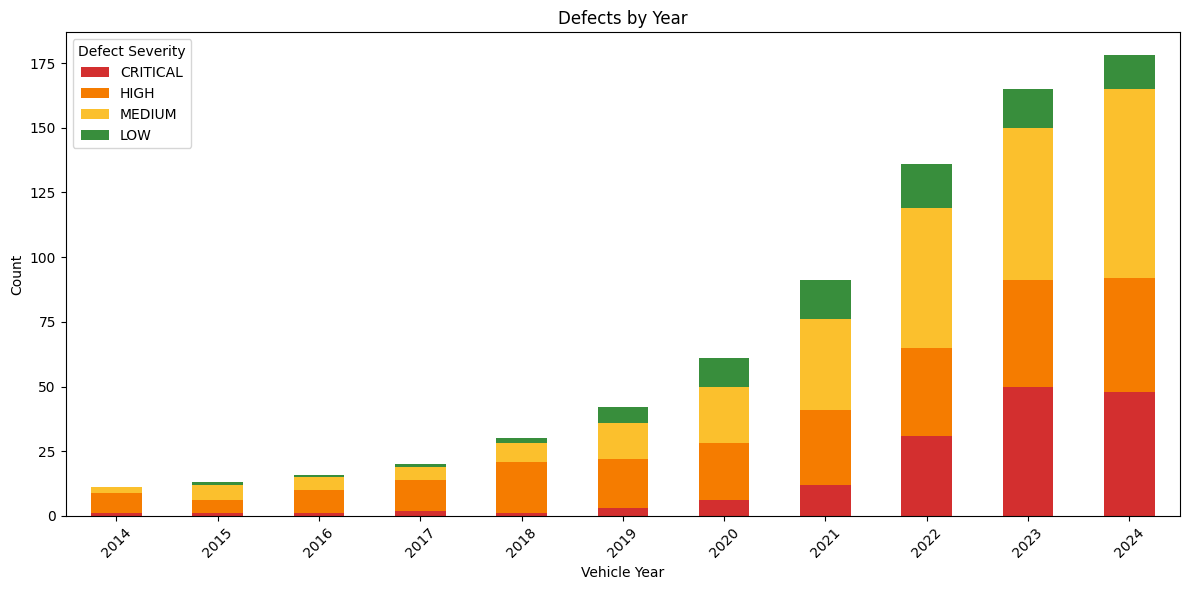

In [14]:
severity_order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']

defects_by_year = (
    df.groupby(['vehicle_year_num', 'defect_severity'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=severity_order)
)

colors = [severity_colors[col] for col in defects_by_year.columns]

fig, ax = plt.subplots(figsize=(12, 6))
defects_by_year.plot(kind='bar', stacked=True, color=colors, ax=ax)

ax.set_title('Defects by Year')
ax.set_xlabel('Vehicle Year')
ax.set_ylabel('Count')
ax.legend(title='Defect Severity')
ax.set_xticklabels([int(y) for y in defects_by_year.index], rotation=45)

plt.tight_layout()
plt.show()

Approach: going more into hybrid or electrical cars + cars fires

# Normalisation

In [15]:
scaler = StandardScaler()
standardized_defect_by_year = scaler.fit_transform(defects_by_year)

_colors = [severity_colors_1[col] for col in standardized_defect_by_year.columns]

_fig1, _ax1 = plt.subplots(figsize=(12, 6))
plt.bar(standardized_defect_by_year, stacked=True, color=_colors, ax=_ax1)
_ax1.set_title('Defect by Year Normalized')
_ax1.set_xlabel('Vehicle Year')
_ax1.set_ylabel('Count')
_ax1.legend(title='Defect Severity')
_ax1.set_xticklabels([int(y) for y in defects_by_year.index], rotation=45)
plt.tight_layout()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'columns'